In [1]:
import matplotlib.pyplot as plt
import numpy as np
import emcee
from scipy.integrate import odeint, solve_ivp 

# First part: integration with option of terminal condition

In [40]:
class Decay:
    def __init__(self, nu=10**(21)):
        self.e0 = 8.854 * 10**-12
        self.barh = 1.054 * 10**-34
        self.e = 1.602 * 10**-19
        self.nu = nu

    
    def ode(self, N, t, Z, v):
        lambda_ = self.nu * np.exp(- 0.5 *Z * self.e*self.e/(self.e0 * self.barh * v)) 
        return -lambda_ * N
    
    def ode_ivp(self, t, N, Z, v):  # signature (t, N)
        lambda_ = self.nu * np.exp(-0.5 * Z * self.e * self.e / (self.e0 * self.barh * v)) 
        return -lambda_ * N
    
    def decay(self, N0, Z, v, T=None, dt=1, t0=0., Nmax=1e4):
        self.N0 = N0

        if T is None: 
            def termination_condition(t, N, Z, v):  
                return N[0] - N0 / 2
            
            termination_condition.terminal = True
            termination_condition.direction = -1  # Terminate when the event crosses zero from below (-1: from above)
            
            sol = solve_ivp(
                self.ode_ivp, 
                [t0, t0 + dt * Nmax], 
                [self.N0], 
                args=(Z, v), 
                events=termination_condition, 
                t_eval=np.arange(t0, t0 + dt * Nmax, dt)
            )
            return sol.t, sol.y[0]
        else:
            t_eval = np.arange(t0, t0 + T, dt)
            sol = odeint(self.ode, self.N0, t_eval, args=(Z, v), printmessg=True)
            return t_eval, sol[:, 0]
    
    def display_decay(self, N0: list, Z: list, v: list, T=None, dt=1, t0=0., Nmax=1e4) -> None:
        if isinstance(dt, (int, float)):
            dt = [float(dt) for i in range(len(v))]

        fig, axes = plt.subplots(2, len(N0), figsize=(5 * len(N0), 10), squeeze=False)

        for i in range(len(N0)):
            t, N = self.decay(N0[i], Z[i], v[i], t0=t0, T=T, dt=dt[i], Nmax=Nmax)
            A = -self.ode_ivp(t, N, Z[i], v[i])
            print("Integration completed for Z=", Z[i])
            # Top plot: Fraction of Particles
            axes[0, i].plot(t, N / N0[i], label=f'N0={N0[i]}, Z={Z[i]}, v={v[i]}')
            axes[0, i].set_xlabel('Time (s)')
            axes[0, i].set_ylabel('Fraction of Particles (N/N0)')
            axes[0, i].set_title(f'Decay Profile {i+1}')
            axes[0, i].legend()
            axes[0, i].set_ylim(-0.1, 1.1)
            axes[0, i].grid(True)

            # Bottom plot: Activity directly below the top plot
            axes[1, i].plot(t, A, color='orange', label=f'Activity')
            axes[1, i].set_xlabel('Time (s)')
            axes[1, i].set_ylabel('Activity (A)')
            axes[1, i].set_title(f'Activity Profile {i+1}')
            axes[1, i].set_yscale('log')
            axes[1, i].legend()
            axes[1, i].grid(True)

        plt.tight_layout()
        plt.show()


## Simulation 
Using
* (a) a Superheavy Nucleus Type-A (Z = 118, high internal velocity v)
* (b) an Intermediate Actinide (Z = 92, moderate internal velocity)
* (c) a Light Unstable Isotope (Z = 20, lower internal velocity scale)

C:\Users\mrtlu\AppData\Local\Temp\ipykernel_15236\4132294405.py:38: ODEintWarning: Integration successful.
  sol = odeint(self.ode, self.N0, t_eval, args=(Z, v), printmessg=True)


0.0 299900.0 0.12666784355691207 1.0


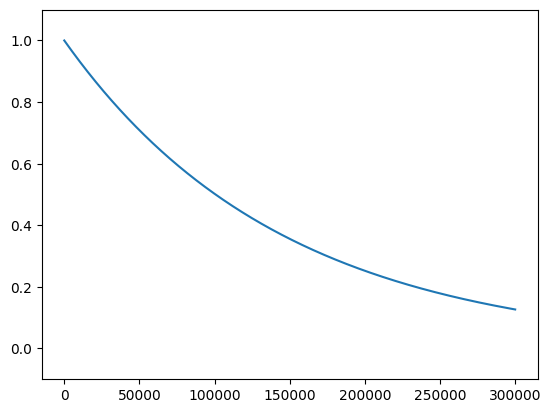

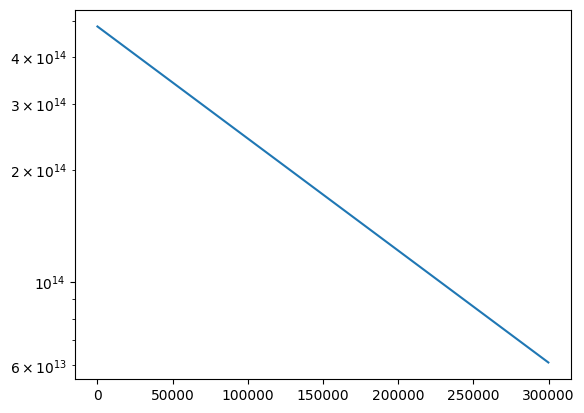

In [53]:
simulation = Decay(nu=10**(21.0000005))  # Using the default nu value
Zs= [118,  92, 20]
c= 3* 1e8 #speed of light in m/s
vs= [0.1*c, 0.07*c, 0.01*c]
N0s= [1e23, 7.0*1e19, 1e23]
dt = [1e1, 1e2, 1e3]

# simulation.display_decay(N0s, Zs, vs, dt=dt, Nmax=1e5)

i = 1
t, N = simulation.decay(N0s[i], Zs[i], vs[i], t0=0., dt=dt[i], Nmax=1e5, T=300000)
print(t.min(), t.max(), N.min()/N0s[i], N.max()/N0s[i])
plt.plot(t, N/N0s[i])
A = -simulation.ode_ivp(t, N, Zs[i], vs[i])
plt.ylim(-0.1, 1.1)
plt.show()
plt.plot(t, A)
plt.yscale('log')
plt.show()


# Second part: Fitting with MC

## 1 Loading of the data and plotting

(16,) (16,) (16,)
Expected N0 is A0/lambda =  6.50e+19


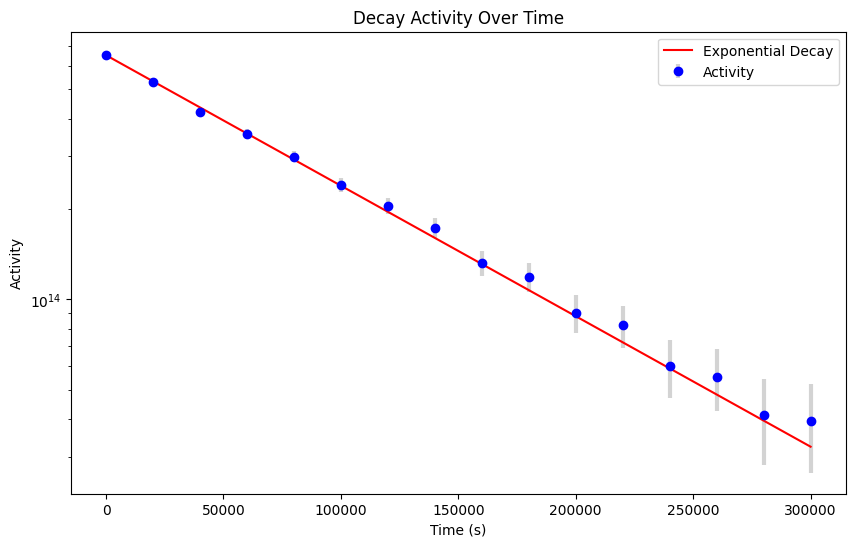

In [4]:
t, A, sA=np.loadtxt("activity_data.txt", unpack=True, usecols=(0, 1, 2))
print(A.shape, t.shape, sA.shape)
#Visualizzation
plt.figure(figsize=(10, 6))
plt.errorbar(t, A, yerr=sA, fmt='o', label='Activity', color='blue', ecolor='lightgray', elinewidth=3, capsize=0)
tl=np.linspace(t.min(), t.max(), 100)
plt.plot(tl, 6.5*1e14 * np.exp(-1e-5 * tl), label='Exponential Decay', color='red')
print(f"Expected N0 is A0/lambda =  {6.5*1e14 / 1e-5:.2e}")
plt.xlabel('Time (s)')
plt.ylabel('Activity')
plt.yscale('log')
plt.title('Decay Activity Over Time')
plt.legend()
plt.show()

## 2 Infer with emcee

Chosen ranges are
$$v\in(0.01\%, 10\%)c$$
$$log_{10}\nu \in(20, 23)$$


In [5]:
def log_likelihood(theta, x, y, yerr):
    log_nu, v = theta

    e0   = 8.854e-12
    barh = 1.054e-34
    e    = 1.602e-19
    # N0   = 1e23
    N0   = 7.0 * 1e19 ##mine
    Z    = 92

    lambda_ = (10**log_nu) * np.exp(-0.5 * Z * e**2 / (e0 * barh * v))
    model   = lambda_ * N0 * np.exp(-lambda_ * x)

    inv_sigma2 = 1.0 / (yerr ** 2)
    return -0.5 * np.sum((y - model) ** 2 * inv_sigma2 + np.log(2*np.pi* (yerr**2)))

In [6]:
def log_prior(theta):
    log_nu, v = theta
    
    # Return a finite value if theta is in the parameter space region with support for the prior
    if 0.0701*c < v < 0.0720*c and -20.5 < log_nu < -21.5:
        return 0.0
    # Otherwise return -infinity, massive down-weight for the posterior
    return -np.inf

In [7]:
def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    # If theta is outside the support for the prior, return -infinity
    if not np.isfinite(lp):
        return -np.inf
    # Otherwise return the logarithm of prior*likelihood, i.e. log_prior + log_likelihood
    return lp + log_likelihood(theta, x, y, yerr)

In [8]:
# The number of walkers
nwalkers = 50

# The dimensionality of the parameter space
ndim = 2

# The MCMC steps each walker needs to take
nmcmc = 5000

# Initial positions of the walkers
pos = np.array([21, 0.071*c]) * (1 + 1e-10* np.random.randn(nwalkers, ndim))

# Run the sampler
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(t, A, sA))
sampler.run_mcmc(pos, nmcmc, progress=True);


  0%|          | 0/5000 [00:00<?, ?it/s]c:\Users\mrtlu\AppData\Local\Programs\Python\Python312\Lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 5000/5000 [00:09<00:00, 546.03it/s]


## Analysis of MC

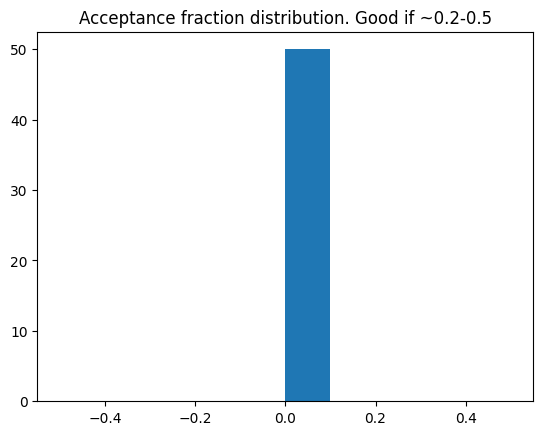

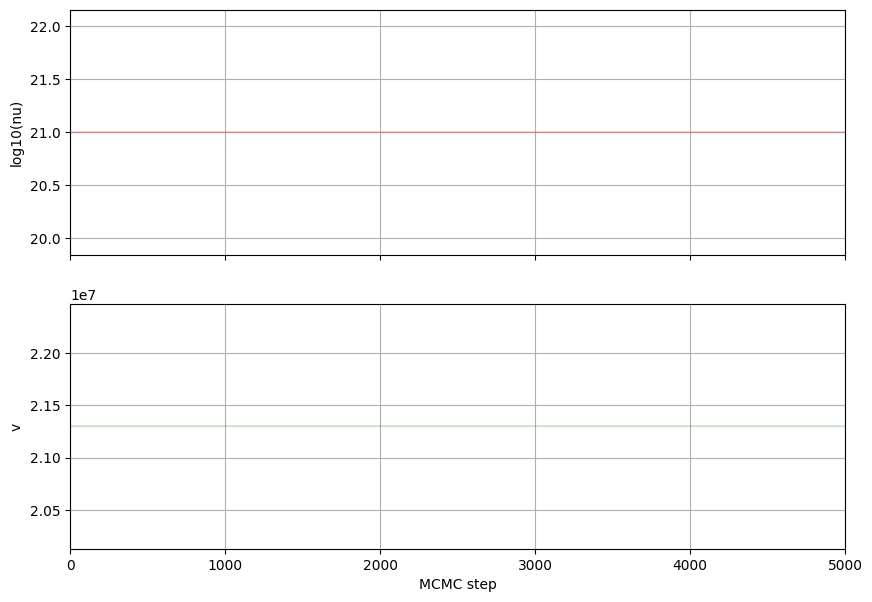

[nan nan]


c:\Users\mrtlu\AppData\Local\Programs\Python\Python312\Lib\site-packages\emcee\autocorr.py:38: RuntimeWarning: invalid value encountered in divide
  acf /= acf[0]


In [9]:
# Gives fraction of steps accepted
plt.hist(sampler.acceptance_fraction, bins=10)
plt.title("Acceptance fraction distribution. Good if ~0.2-0.5");
plt.show()

#Plot of parameters vs steps
fig, axes = plt.subplots(2, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["log10(nu)", "v"]
col = ['r', 'g']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, 0, i], col[i], alpha=0.2)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    # ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.grid()
axes[-1].set_xlabel("MCMC step")
plt.show()

# Finally we get the autocorrelation time to avoid dependence with initial condition and between themselves
tau = sampler.get_autocorr_time(quiet=True)
print(tau)

In [10]:
tau.shape, samples.shape

((2,), (5000, 50, 2))

In [11]:
flat_samples = sampler.get_chain(discard=200, thin=int(np.mean(tau)), flat=True)
#discard the first 200 and take one sample each time correlation mean
print(flat_samples.shape)

ValueError: cannot convert float NaN to integer

### Plot of the behaviour

0.0 300000.0
Labda= 8.991797291899359e-06 log_nu= 20.932761651732342 v/c= 0.07049280172402822
Labda= 9.204371548870513e-06 log_nu= 20.675993082439152 v/c= 0.07122458733935003
Labda= 9.086979066304459e-06 log_nu= 20.594382628474776 v/c= 0.0714358382808623
Labda= 9.175527893582283e-06 log_nu= 20.883150222868316 v/c= 0.07065161398697847
Labda= 9.068303246184647e-06 log_nu= 20.840974034550385 v/c= 0.07075280365484808
Labda= 9.099725019316497e-06 log_nu= 20.995695637043177 v/c= 0.07033644084885496
Labda= 9.172562613641379e-06 log_nu= 20.826249521054716 v/c= 0.07080666525928873
Labda= 8.970944369207748e-06 log_nu= 20.894924998145534 v/c= 0.07059287581316716
Labda= 9.134446442044982e-06 log_nu= 21.07172801742146 v/c= 0.07013608452998454
Labda= 9.228980634392752e-06 log_nu= 20.953290532309754 v/c= 0.0704677879954069


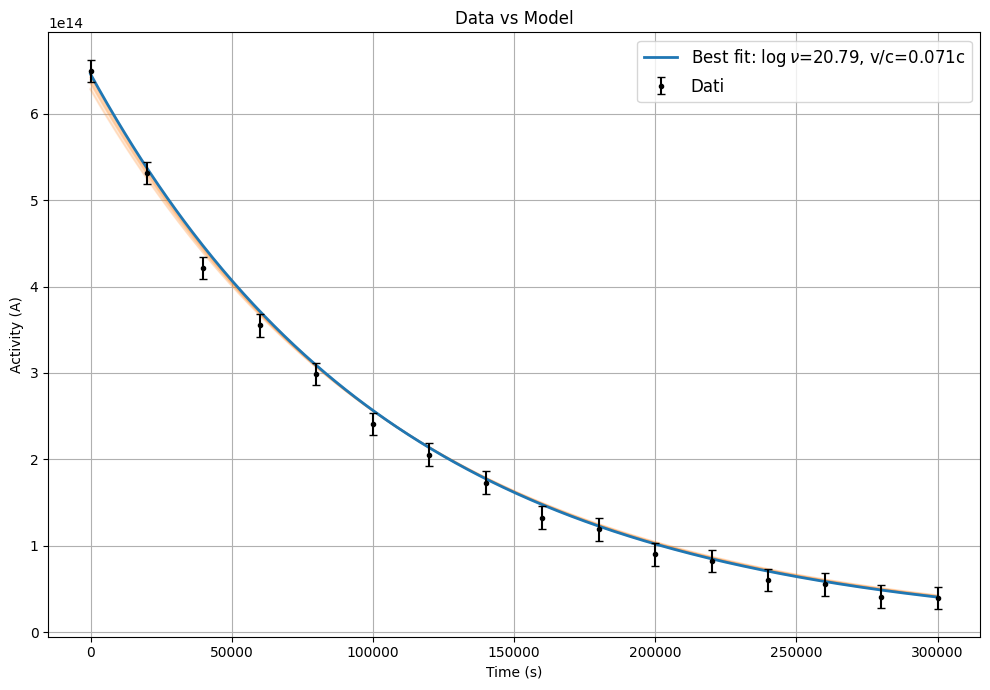

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

t_plot = np.linspace(t.min(), t.max(), 500)
print(t_plot.min(), t_plot.max())
N0 = 7.0 * 1e19
e0   = 8.854e-12
barh = 1.054e-34
e    = 1.602e-19
Z    = 92

# ── 100 from posterior ──────────────────────────────────────────────
inds = np.random.randint(len(flat_samples), size=10)
for ind in inds:
    log_nu, v = flat_samples[ind]

    lambda_ = (10**log_nu) * np.exp(-0.5 * Z * e**2 / (e0 * barh * v))
    model   = lambda_ * N0 * np.exp(-lambda_ * t_plot)
    print("Labda=", lambda_, "log_nu=", log_nu, "v/c=", v/c)
    ax.plot(t_plot, model, "C1", alpha=0.15)

#data
ax.errorbar(t, A, yerr=sA, fmt=".k", capsize=3, label="Dati", zorder=5)
#best fit
log_nu_med, v_med = np.median(flat_samples, axis=0)

lambda_ = (10**log_nu) * np.exp(-0.5 * Z * e**2 / (e0 * barh * v))
model_best = lambda_ * N0 * np.exp(-lambda_ * t_plot)


ax.plot(t_plot, model_best, "C0", lw=2,
        label=rf"Best fit: $\log\nu$={log_nu_med:.2f}, v/c={v_med/c:.3f}c")

# ax.set_yscale("log")
ax.set_xlabel("Time (s)")
# ax.set_yscale('log')
ax.set_ylabel("Activity (A)")
ax.set_title("Data vs Model")
ax.legend(fontsize=12)
ax.grid(True)
plt.tight_layout()
plt.show()

# 3) Corner Plot and credible intervals

<Figure size 1000x800 with 0 Axes>

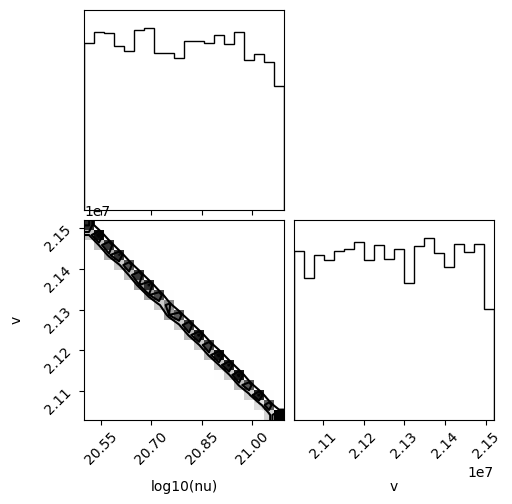

In [ ]:
import corner
plt.figure(figsize=(10, 8))
fig = corner.corner(flat_samples, labels=labels)
plt.show()

## Print of 90% credible intervals


In [ ]:
ptile = np.percentile(flat_samples[:, 0], [5, 50, 95])
interval = np.diff(ptile)
print(f"{labels[0]} = {ptile[1]:.3f} +{interval[1]:.3f} -{interval[0]:.3f}")

ptile = np.percentile(flat_samples[:, 1], [5, 50, 95])
interval = np.diff(ptile)
print(f"{labels[1]}/c = {ptile[1]/c:.3f} +{interval[1]/c:.3f} -{interval[0]/c:.3f}")

log10(nu) = 20.790 +0.266 -0.261
v/c = 0.071 +0.001 -0.001
